# 02 · Data Cleaning

[← Course home](../README.md)

Real data is incomplete, inconsistent and occasionally wrong. Models do not complain — they silently
learn from whatever you feed them. This chapter turns cleaning into a set of deliberate, testable steps.

**What you will learn**

- How to *see* missing data, and the MCAR / MAR / MNAR vocabulary for reasoning about it.
- Deletion vs simple vs group-wise vs model-based imputation (`KNNImputer`, `IterativeImputer`), and
  when a *missing-indicator* feature helps.
- Outlier detection with IQR, z-score, robust z (MAD) and domain limits — and what to do with outliers.
- Exact and near-duplicate detection.
- Fixing dtypes: strings → numbers, categoricals, booleans, dates.
- An end-to-end exercise: building a deliberately messy Auto-MPG file and cleaning it with a reusable
  `clean_mpg()` function plus assertion-based validation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (activates IterativeImputer)
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

from mlaz import set_style, savefig, PALETTE, load_titanic, load_mpg

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

## 1. Missing values

### 1.1 Look before you impute

In [2]:
titanic = load_titanic()
missing = titanic.isna().sum().to_frame("n_missing")
missing["pct"] = (100 * missing["n_missing"] / len(titanic)).round(1)
missing.sort_values("n_missing", ascending=False).head(6)

,n_missing,pct
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2
sex,0,0.0
pclass,0,0.0


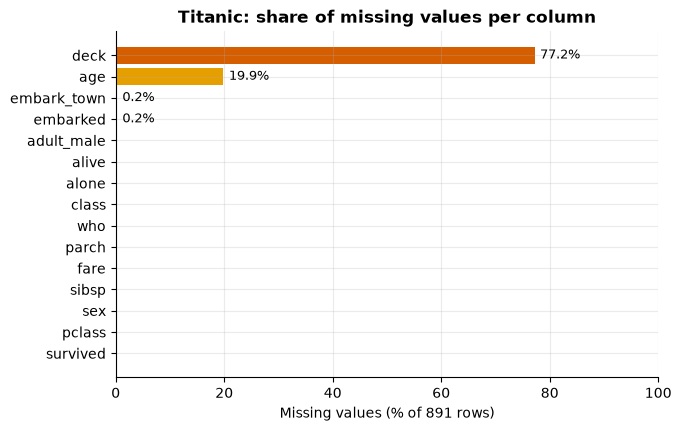

In [3]:
miss_pct = titanic.isna().mean().sort_values() * 100
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [PALETTE[3] if v > 50 else PALETTE[1] if v > 0 else PALETTE[0] for v in miss_pct]
ax.barh(miss_pct.index, miss_pct.values, color=colors)
for i, v in enumerate(miss_pct.values):
    if v > 0:
        ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Missing values (% of 891 rows)")
ax.set_xlim(0, 100)
ax.set_title("Titanic: share of missing values per column")
savefig("missing_bar")
plt.show()

The bar chart tells us *how much*; a **missingness matrix** tells us *where*. Each row of the image is a
passenger (sorted by class), each column a feature; dark cells are missing.

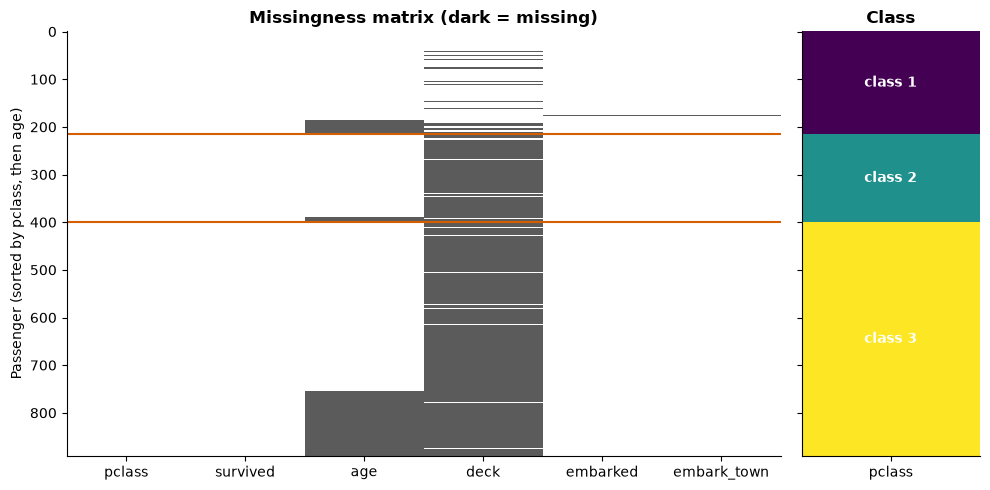

In [4]:
order = titanic.sort_values(["pclass", "age"]).index
cols_with_na = ["age", "deck", "embarked", "embark_town"]
show_cols = ["pclass", "survived"] + cols_with_na
M = titanic.loc[order, show_cols].isna().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={"width_ratios": [4, 1]}, sharey=True)
axes[0].imshow(M, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1.4)
axes[0].set_xticks(range(len(show_cols)), show_cols)
axes[0].set_ylabel("Passenger (sorted by pclass, then age)")
axes[0].set_title("Missingness matrix (dark = missing)")
axes[0].grid(False)
pcls = titanic.loc[order, "pclass"].to_numpy()
for c in (1, 2):
    b = np.argmax(pcls > c)
    axes[0].axhline(b - 0.5, color=PALETTE[3], lw=1.5)
axes[1].imshow(pcls[:, None], aspect="auto", cmap="viridis", interpolation="nearest")
axes[1].set_xticks([0], ["pclass"])
for c in (1, 2, 3):
    mid = np.mean(np.where(pcls == c)[0])
    axes[1].text(0, mid, f"class {c}", ha="center", va="center", color="white", fontweight="bold")
axes[1].set_title("Class")
axes[1].grid(False)
fig.tight_layout()
savefig("missingness_matrix")
plt.show()

The pattern is not random: `deck` is known for most 1st-class passengers and almost no 3rd-class
ones; `age` is missing much more often in 3rd class.

### 1.2 Why is it missing? MCAR, MAR, MNAR

| Mechanism | Meaning | Example | Consequence |
|---|---|---|---|
| **MCAR** — missing completely at random | $P(\text{missing})$ unrelated to any data | a sensor randomly drops packets | deletion is unbiased (only loses power) |
| **MAR** — missing at random | depends on *observed* columns | age missing more often in 3rd class | impute using those columns |
| **MNAR** — missing not at random | depends on the *unobserved value itself* | high earners skip the income question | no imputation fully fixes it; the missingness is information |

We can test MCAR-vs-MAR against observed columns (never MNAR — that needs domain knowledge).

In [5]:
rates = pd.DataFrame({
    "age missing (%)": titanic.groupby("pclass")["age"].apply(lambda s: 100 * s.isna().mean()),
    "deck missing (%)": titanic.groupby("pclass")["deck"].apply(lambda s: 100 * s.isna().mean()),
}).round(1)
surv = pd.DataFrame({
    "survival if age known": titanic.groupby(titanic["age"].isna())["survived"].mean(),
    "survival if deck known": titanic.groupby(titanic["deck"].isna())["survived"].mean(),
}).rename(index={False: "value present", True: "value missing"}).round(3)
display(rates)
display(surv)

,age missing (%),deck missing (%)
pclass,,
1,13.9,19.0
2,6.0,91.3
3,27.7,97.6


,survival if age known,survival if deck known
value present,0.406,0.670
value missing,0.294,0.299


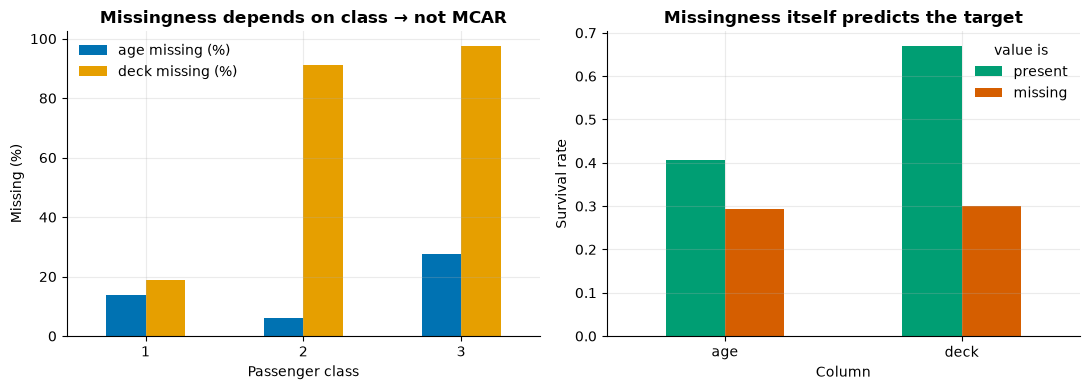

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rates.plot.bar(ax=axes[0], color=[PALETTE[0], PALETTE[1]], rot=0)
axes[0].set_xlabel("Passenger class")
axes[0].set_ylabel("Missing (%)")
axes[0].set_title("Missingness depends on class → not MCAR")
surv_plot = pd.DataFrame({
    "age": titanic.groupby(titanic["age"].isna())["survived"].mean(),
    "deck": titanic.groupby(titanic["deck"].isna())["survived"].mean(),
}).rename(index={False: "present", True: "missing"}).T
surv_plot.plot.bar(ax=axes[1], color=[PALETTE[2], PALETTE[3]], rot=0)
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Survival rate")
axes[1].set_title("Missingness itself predicts the target")
axes[1].legend(title="value is")
fig.tight_layout()
savefig("missingness_mechanism")
plt.show()

Passengers with a recorded deck survived 67 % of the time vs 30 % without one. Throwing that column
away (or imputing it and forgetting it was missing) discards a strong signal.

### 1.3 Strategies

| Strategy | How | Pros | Cons |
|---|---|---|---|
| Listwise deletion | `df.dropna()` | simple, unbiased if MCAR | loses rows (here 80 % if we require `deck`!) |
| Column deletion | drop `deck` | simple | loses signal |
| Mean / median / mode | `SimpleImputer` | fast, pipeline-friendly | shrinks variance, distorts distribution & correlations |
| Group-wise | median age per (class, sex) | uses MAR structure | must be computed on train only |
| KNN | `KNNImputer` | local, multivariate | needs scaling, slow for big data |
| Iterative (MICE-like) | `IterativeImputer` | models each column from the others | slower, can extrapolate |
| + missing indicator | `add_indicator=True` | lets the model use the missingness | extra columns |

**How good is each imputer?** We can only measure it where we know the truth: hide 20 % of the
*known* ages, impute them, and compare with the real values.

In [7]:
df = titanic[["pclass", "sex", "sibsp", "parch", "fare", "age"]].copy()
df["sex"] = (df["sex"] == "female").astype(int)
known = df.index[df["age"].notna()]
hide = rng.choice(known, size=int(0.2 * len(known)), replace=False)
df_masked = df.copy()
df_masked.loc[hide, "age"] = np.nan
true_age = df.loc[hide, "age"]
feat = ["pclass", "sex", "sibsp", "parch", "fare", "age"]

def scaled_impute(imputer, frame):
    """Scale -> impute -> unscale, so distance/regression-based imputers see comparable units."""
    scaler = StandardScaler().fit(frame)            # StandardScaler ignores NaN when fitting
    Z = imputer.fit_transform(scaler.transform(frame))
    return pd.DataFrame(scaler.inverse_transform(Z), index=frame.index, columns=frame.columns)

imputed = {
    "mean": df_masked["age"].fillna(df_masked["age"].mean()),
    "median": df_masked["age"].fillna(df_masked["age"].median()),
    "group median\n(pclass × sex)": df_masked["age"].fillna(
        df_masked.groupby(["pclass", "sex"])["age"].transform("median")),
    "KNN (k=5)": scaled_impute(KNNImputer(n_neighbors=5), df_masked[feat])["age"],
    "iterative": scaled_impute(IterativeImputer(random_state=RANDOM_STATE, max_iter=20), df_masked[feat])["age"],
}
err = pd.DataFrame({
    name: {"MAE (years)": np.mean(np.abs(s[hide] - true_age)),
           "RMSE (years)": np.sqrt(np.mean((s[hide] - true_age) ** 2)),
           "std of imputed ages": s[hide].std()}
    for name, s in imputed.items()
}).T.round(2)
err.index = [i.replace("\n", " ") for i in err.index]
print(f"true std of the hidden ages: {true_age.std():.2f} years")
err

true std of the hidden ages: 12.44 years


,MAE (years),RMSE (years),std of imputed ages
mean,9.95,12.41,0.00
median,9.81,12.40,0.00
group median (pclass × sex),9.70,12.57,7.21
KNN (k=5),9.91,12.92,11.20
iterative,9.62,12.12,7.74


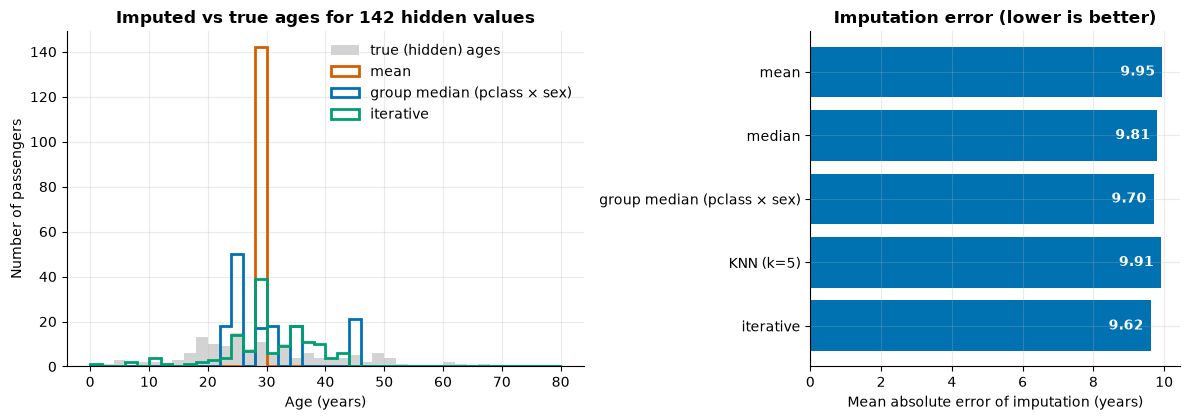

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [1.4, 1]})
bins = np.arange(0, 82, 2)
axes[0].hist(true_age, bins=bins, color="lightgrey", label="true (hidden) ages")
for (name, s), c in zip([("mean", imputed["mean"]), ("group median\n(pclass × sex)", imputed["group median\n(pclass × sex)"]),
                         ("iterative", imputed["iterative"])], [PALETTE[3], PALETTE[0], PALETTE[2]]):
    axes[0].hist(s[hide], bins=bins, histtype="step", lw=2, color=c, label=name.replace("\n", " "))
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Number of passengers")
axes[0].set_title("Imputed vs true ages for 142 hidden values")
axes[0].legend()
names = [n.replace("\n", " ") for n in imputed]
axes[1].barh(names, err["MAE (years)"], color=PALETTE[0])
for i, v in enumerate(err["MAE (years)"]):
    axes[1].text(v - 0.2, i, f"{v:.2f}", va="center", ha="right", color="white", fontweight="bold")
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean absolute error of imputation (years)")
axes[1].set_title("Imputation error (lower is better)")
fig.tight_layout()
savefig("imputation_comparison")
plt.show()

Two lessons. First, the *pointwise* errors are surprisingly similar (MAE 9.6–9.9 years): these
columns simply do not predict age very well, and no imputer can recover information that is not there.
The iterative imputer is best (MAE 9.62 vs 9.95 for the mean). Second, the *distributions* differ
enormously: mean/median imputation piles every missing value onto one spike (std = 0), which shrinks the
variance of `age` and weakens every correlation involving it. Group-wise and model-based imputers
produce spread-out values that respect the MAR structure (older passengers in 1st class).

### 1.4 Missing indicators inside a pipeline

In a real model, imputation must be **fit on the training folds only** — so it lives in the pipeline.
`add_indicator=True` appends a 0/1 column "was this value missing?" for every column that had NaNs.

In [9]:
Xt = titanic[["pclass", "sex", "age", "sibsp", "parch", "fare", "deck"]].copy()
Xt["deck"] = Xt["deck"].fillna("missing")    # for categoricals, "missing" as its own category = indicator
yt = titanic["survived"]
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

def make_model(add_indicator, use_deck):
    num = ["pclass", "age", "sibsp", "parch", "fare"]
    cat = ["sex"] + (["deck"] if use_deck else [])
    pre = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median", add_indicator=add_indicator), StandardScaler()), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ])
    return Pipeline([("pre", pre), ("model", LogisticRegression(max_iter=1000))])

rows = []
for use_deck in (False, True):
    for ind in (False, True):
        s = cross_val_score(make_model(ind, use_deck), Xt, yt, cv=cv)
        rows.append({"deck (with 'missing' level)": use_deck, "age missing-indicator": ind,
                     "CV accuracy": f"{s.mean():.3f} ± {s.std():.3f}"})
pd.DataFrame(rows)

,deck (with 'missing' level),age missing-indicator,CV accuracy
0,False,False,0.790 ± 0.012
1,False,True,0.791 ± 0.017
2,True,False,0.798 ± 0.027
3,True,True,0.797 ± 0.029


Encoding "deck unknown" as its own category turns 77 % missing data into a useful feature (+0.8
percentage points), whereas the age indicator adds nothing measurable here — logistic regression can
already partly infer "age unknown" from class. Indicators are cheap, so try them, but let CV decide.

## 2. Outliers

An **outlier** is a value far from the rest. It can be (a) a data-entry error, (b) a legitimate but
rare value, or (c) a sign that the row belongs to another population. Detection rules for a column $x$:

- **IQR (Tukey) fences:** outside $[Q_1 - 1.5\,\mathrm{IQR},\; Q_3 + 1.5\,\mathrm{IQR}]$.
- **z-score:** $|z| = |x - \bar x| / s > 3$. Uses the mean and std — which are themselves pulled by outliers.
- **Robust z (MAD):** $|x - \tilde x| / (1.4826 \cdot \mathrm{MAD}) > 3.5$, where
  $\mathrm{MAD} = \mathrm{median}(|x - \tilde x|)$. Median-based, so outliers cannot hide themselves.
- **Domain limits:** physically / logically impossible values (negative age, 0-second acceleration).

In [10]:
fare = titanic["fare"]
q1, q3 = fare.quantile([0.25, 0.75])
iqr = q3 - q1
iqr_hi = q3 + 1.5 * iqr
z = (fare - fare.mean()) / fare.std()
med = fare.median()
mad = np.median(np.abs(fare - med))
robust_z = (fare - med) / (1.4826 * mad)
rules = pd.DataFrame({
    "upper threshold (£)": [iqr_hi, fare.mean() + 3 * fare.std(), med + 3.5 * 1.4826 * mad],
    "n flagged": [(fare > iqr_hi).sum(), (z.abs() > 3).sum(), (robust_z.abs() > 3.5).sum()],
}, index=["IQR fence", "z-score > 3", "robust z > 3.5"]).round(1)
print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, median={med:.2f}, MAD={mad:.2f}")
print(f"fares equal to 0: {(fare == 0).sum()}  (domain question: crew? complimentary tickets?)")
rules

Q1=7.91, Q3=31.00, IQR=23.09, median=14.45, MAD=6.90
fares equal to 0: 15  (domain question: crew? complimentary tickets?)


,upper threshold (£),n flagged
IQR fence,65.6,116
z-score > 3,181.3,20
robust z > 3.5,50.3,160


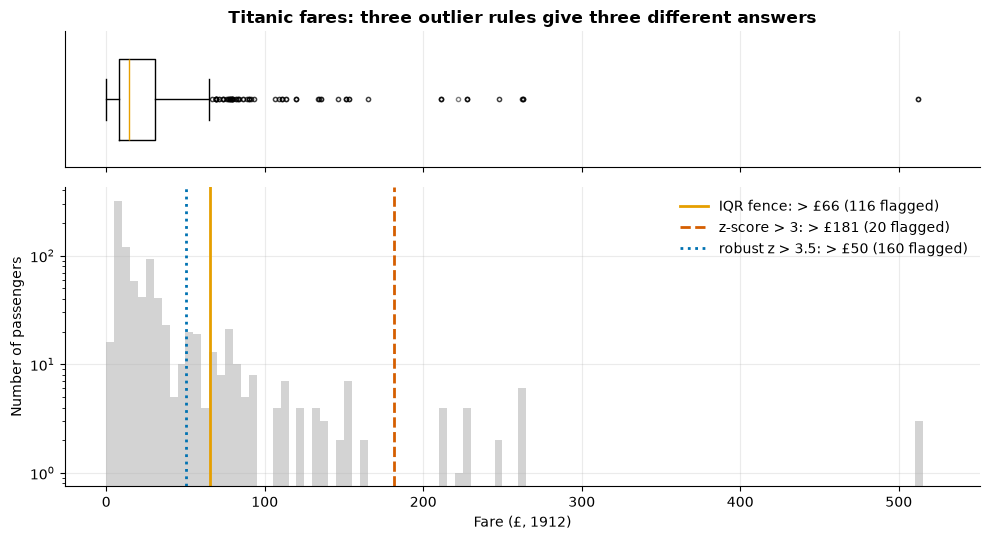

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True, gridspec_kw={"height_ratios": [1, 2.2]})
axes[0].boxplot(fare, orientation="horizontal", widths=0.6, flierprops=dict(marker="o", markersize=3, alpha=0.5))
axes[0].set_yticks([])
axes[0].set_title("Titanic fares: three outlier rules give three different answers")
axes[1].hist(fare, bins=np.arange(0, 530, 5), color="lightgrey")
for (name, row), c, ls in zip(rules.iterrows(), [PALETTE[1], PALETTE[3], PALETTE[0]], ["-", "--", ":"]):
    axes[1].axvline(row["upper threshold (£)"], color=c, lw=2, ls=ls,
                    label=f"{name}: > £{row['upper threshold (£)']:.0f} ({int(row['n flagged'])} flagged)")
axes[1].set_xlabel("Fare (£, 1912)")
axes[1].set_ylabel("Number of passengers")
axes[1].set_yscale("log")
axes[1].legend(loc="upper right")
fig.tight_layout()
savefig("outlier_rules")
plt.show()

Fares are **right-skewed**: 116 "outliers" by the IQR rule are simply 1st-class tickets — legitimate.
For skewed positive data, a log transform is often a better answer than deleting anything:

In [12]:
log_fare = np.log1p(fare)
q1l, q3l = log_fare.quantile([0.25, 0.75])
print("IQR outliers on log(1+fare):", ((log_fare < q1l - 1.5 * (q3l - q1l)) | (log_fare > q3l + 1.5 * (q3l - q1l))).sum())
print(f"skewness fare: {fare.skew():.2f}   log1p(fare): {log_fare.skew():.2f}")

IQR outliers on log(1+fare): 31
skewness fare: 4.79   log1p(fare): 0.39


### What to do with an outlier

| Option | When |
|---|---|
| **Fix** | it is a typo and the true value can be recovered (e.g. unit error) |
| **Drop / set to NaN** | it is impossible (domain limit) and cannot be recovered |
| **Winsorise** (clip to a percentile) | legitimate but extreme values dominate a sensitive model |
| **Transform** (log, rank) | skewed positive data |
| **Keep** | legitimate values and a robust model (trees, Huber loss) |

Below we corrupt 3 cars in Auto-MPG with typical entry errors (an extra zero in `horsepower`) and
compare an OLS fit of `mpg` on `horsepower` under each option.

In [13]:
mpg = load_mpg().dropna(subset=["horsepower"]).reset_index(drop=True)
bad = mpg.copy()
typo_idx = mpg.sort_values("horsepower").index[[150, 250, 300]]
bad.loc[typo_idx, "horsepower"] *= 10     # 95 -> 950 etc.
print(bad.loc[typo_idx, ["name", "horsepower", "mpg"]])

def fit_line(frame):
    lr = LinearRegression().fit(frame[["horsepower"]], frame["mpg"])
    return lr.coef_[0], lr.intercept_

lo, hi = bad["horsepower"].quantile([0.01, 0.99])
variants = {
    "clean data (truth)": mpg,
    "keep typos": bad,
    "drop (domain limit hp ≤ 500)": bad[bad["horsepower"] <= 500],
    "winsorise at 1st/99th pct": bad.assign(horsepower=bad["horsepower"].clip(lo, hi)),
}
fits = pd.DataFrame({k: fit_line(v) for k, v in variants.items()}, index=["slope (mpg per hp)", "intercept"]).T.round(3)
fits

                          name  horsepower   mpg
18                datsun pl510       880.0  27.0
321                 dodge colt      1050.0  27.9
0    chevrolet chevelle malibu      1300.0  18.0


,slope (mpg per hp),intercept
clean data (truth),-0.158,39.936
keep typos,-0.026,26.363
drop (domain limit hp ≤ 500),-0.158,39.916
winsorise at 1st/99th pct,-0.147,38.883


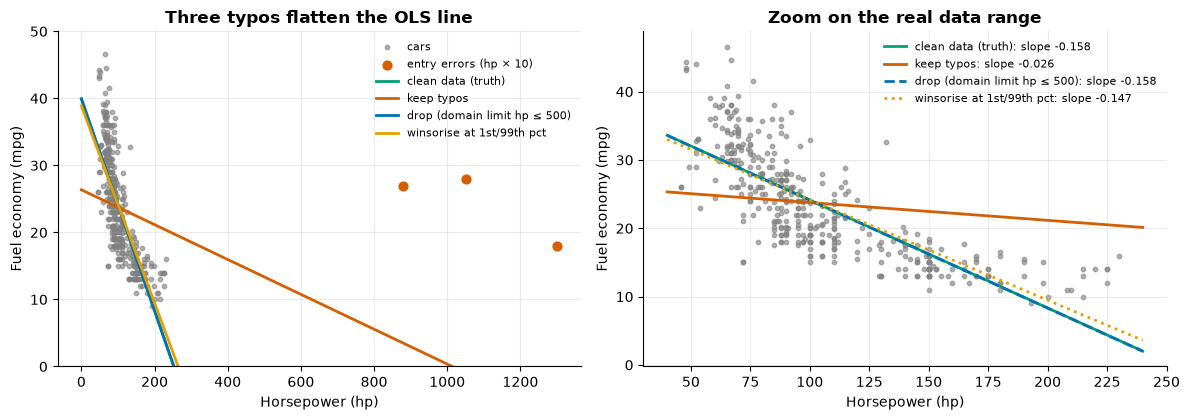

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].scatter(bad["horsepower"], bad["mpg"], s=10, color="grey", alpha=0.6, label="cars")
axes[0].scatter(bad.loc[typo_idx, "horsepower"], bad.loc[typo_idx, "mpg"], s=40, color=PALETTE[3],
                label="entry errors (hp × 10)")
xs = np.linspace(0, bad["horsepower"].max(), 100)
for (name, (b, a)), c in zip(fits.iterrows(), [PALETTE[2], PALETTE[3], PALETTE[0], PALETTE[1]]):
    axes[0].plot(xs, a + b * xs, color=c, lw=2, label=name)
axes[0].set_ylim(0, 50)
axes[0].set_xlabel("Horsepower (hp)")
axes[0].set_ylabel("Fuel economy (mpg)")
axes[0].set_title("Three typos flatten the OLS line")
axes[0].legend(fontsize=8, loc="upper right")
xs2 = np.linspace(40, 240, 100)
axes[1].scatter(mpg["horsepower"], mpg["mpg"], s=10, color="grey", alpha=0.6)
for (name, (b, a)), c, ls in zip(fits.iterrows(), [PALETTE[2], PALETTE[3], PALETTE[0], PALETTE[1]], ["-", "-", "--", ":"]):
    axes[1].plot(xs2, a + b * xs2, color=c, lw=2, ls=ls, label=f"{name}: slope {b:.3f}")
axes[1].set_xlabel("Horsepower (hp)")
axes[1].set_ylabel("Fuel economy (mpg)")
axes[1].set_title("Zoom on the real data range")
axes[1].legend(fontsize=8, loc="upper right")
fig.tight_layout()
savefig("outlier_treatment")
plt.show()

Three wrong rows out of 392 cut the slope by more than half. Dropping impossible values restores it
almost exactly; winsorising helps but still leaves the errors at a (wrong) high value.

## 3. Duplicates

**Exact duplicates** are identical rows. Whether they are errors depends on the data: Titanic has no
passenger ID or name, so identical rows can be *different people* with the same attributes.

In [15]:
dups = titanic.duplicated(keep=False)
print(f"exact duplicate rows in titanic: {titanic.duplicated().sum()} "
      f"({dups.sum()} rows involved)")
titanic[dups].sort_values(["pclass", "sex", "age", "fare"]).head(6)

exact duplicate rows in titanic: 107 (160 rows involved)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
369,1,1,female,24.0,0,0,69.3000,C,First,woman,False,B,Cherbourg,yes,True
641,1,1,female,24.0,0,0,69.3000,C,First,woman,False,B,Cherbourg,yes,True
64,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
295,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
443,1,2,female,28.0,0,0,13.0000,S,Second,woman,False,NaN,Southampton,yes,True
635,1,2,female,28.0,0,0,13.0000,S,Second,woman,False,NaN,Southampton,yes,True


These are mostly 3rd-class men with missing age paying the standard fare — plausibly distinct people.
**Never drop duplicates blindly**: first ask whether the table has a natural key (an ID) and whether two
identical rows could legitimately describe two entities.

**Near-duplicates** differ only in formatting ("Ford Pinto " vs "ford pinto"), units or rounding. They
only become visible after normalisation — which is exactly what the Auto-MPG exercise below does.

## 4. Data types

Common conversions (all demonstrated on the messy file below):

| Problem | Tool |
|---|---|
| numbers stored as text (`"130"`, `"130 hp"`, `"?"`) | `str.extract`, `pd.to_numeric(errors="coerce")` |
| a small set of repeated strings | `astype("category")` — less memory, fixed levels |
| `"yes"/"no"/"Y"/"1"` | explicit `map` to `bool` |
| dates as text | `pd.to_datetime(errors="coerce")` |

In [16]:
s = pd.Series(["130", " 95", "?", "88 hp", "", None])
print(pd.to_numeric(s.str.extract(r"(\d+\.?\d*)")[0], errors="coerce").tolist())
o = pd.Series(["usa", "japan", "usa", "europe"] * 1000)
print(f"object/string memory: {o.memory_usage(deep=True):,} bytes   category: {o.astype('category').memory_usage(deep=True):,} bytes")

[130.0, 95.0, nan, 88.0, nan, nan]
object/string memory: 245,132 bytes   category: 4,317 bytes


## 5. End-to-end: cleaning a messy Auto-MPG file

We now build a **deliberately messy** copy of `mpg.csv` — deterministically, so everyone gets the same
mess — that mimics a file merged from several sources:

- fuel economy reported either in **mpg** or **L/100 km** (with a unit column),
- weight either in **lb** or **kg** (with a unit column),
- horsepower as text, with `"?"` for unknown and a few `"hp"` suffixes,
- `origin` with inconsistent case, whitespace and abbreviations,
- model year sometimes as `70`, sometimes as `1970`,
- a boolean `turbo` column spelled five different ways, and a `registered` date as text,
- three entry errors (impossible values),
- exact duplicate rows *and* near-duplicates (same car, different formatting/units).

In [17]:
LB_PER_KG = 2.20462
L100KM_FROM_MPG = 235.215            # L/100km = 235.215 / mpg (US gallons)

def make_messy_mpg(seed=RANDOM_STATE):
    r = np.random.default_rng(seed)
    raw = load_mpg()
    n = len(raw)
    m = pd.DataFrame(index=raw.index)
    # fuel economy in two units
    metric_fuel = r.random(n) < 0.3
    m["fuel_economy"] = np.where(metric_fuel, (L100KM_FROM_MPG / raw["mpg"]).round(2), raw["mpg"])
    m["fuel_unit"] = np.where(metric_fuel, "L/100km", "mpg")
    m["cylinders"] = raw["cylinders"]
    m["displacement"] = raw["displacement"]
    # horsepower as messy text
    hp = raw["horsepower"].astype("Int64").astype(str).replace("<NA>", "?")
    suffix = r.random(n) < 0.1
    m["horsepower"] = np.where(suffix & (hp != "?"), hp + " hp", hp)
    # weight in two units
    metric_w = (raw["origin"] != "usa") & (r.random(n) < 0.7)
    m["weight"] = np.where(metric_w, (raw["weight"] / LB_PER_KG).round(1), raw["weight"])
    m["weight_unit"] = np.where(metric_w, "kg", "lb")
    m["acceleration"] = raw["acceleration"]
    # two-digit and four-digit years
    four = r.random(n) < 0.4
    m["model_year"] = np.where(four, raw["model_year"] + 1900, raw["model_year"])
    # origin spelled inconsistently
    variants = {"usa": ["usa", "USA", " usa", "U.S.A.", "Usa "],
                "japan": ["japan", "Japan", "JAPAN ", " japan"],
                "europe": ["europe", "Europe", "EUROPE", "eur ", "Europe "]}
    m["origin"] = [variants[o][r.integers(len(variants[o]))] for o in raw["origin"]]
    # names with case / whitespace noise
    noisy = r.random(n) < 0.15
    m["name"] = np.where(noisy, "  " + raw["name"].str.title() + " ", raw["name"])
    # a boolean flag spelled in many ways (fictional, for the exercise)
    turbo = r.random(n) < 0.12
    m["turbo"] = [str(r.choice(["yes", "Y", "TRUE", "1"])) if t else str(r.choice(["no", "N", "false", "0"])) for t in turbo]
    # registration date as text (fictional), a few unknown
    day = r.integers(0, 365, n)
    reg = pd.to_datetime((raw["model_year"] + 1900).astype(str) + "-01-01") + pd.to_timedelta(day, unit="D")
    m["registered"] = reg.dt.strftime("%Y-%m-%d")
    m.loc[r.choice(n, 5, replace=False), "registered"] = "unknown"
    # three entry errors
    m.loc[10, "acceleration"] = 0.0          # impossible: 0 s to 60 mph
    m.loc[20, "cylinders"] = 0                # impossible: engine without cylinders
    m.loc[30, "displacement"] = -97.0         # impossible: negative volume
    # exact duplicates and near-duplicates (same car, other formatting)
    exact = m.loc[r.choice(n, 8, replace=False)]
    near = m.loc[[50, 60, 70, 80]].copy()
    near["name"] = near["name"].str.upper() + "  "
    near["origin"] = near["origin"].str.strip().str.lower() + " "
    near["weight"] = np.where(near["weight_unit"] == "lb", (near["weight"] / LB_PER_KG).round(1), near["weight"])
    near["weight_unit"] = "kg"
    messy = pd.concat([m, exact, near])
    return messy.sample(frac=1, random_state=seed)   # shuffle; keep original index as hidden "truth" key

messy = make_messy_mpg()
print(messy.shape)
messy.head(8)

(410, 13)


,fuel_economy,fuel_unit,cylinders,displacement,horsepower,weight,weight_unit,acceleration,model_year,origin,name,turbo,registered
172,9.41,L/100km,4,90.0,71,1008.3,kg,16.5,1975,europe,volkswagen dasher,Y,1975-01-07
137,13.00,mpg,8,350.0,150,4699.0,lb,14.5,74,usa,Buick Century Luxus (Sw),0,1974-10-04
126,21.00,mpg,6,200.0,NaN,2875.0,lb,17.0,74,usa,ford maverick,no,1974-09-20
94,13.00,mpg,8,440.0,215,4735.0,lb,11.0,73,Usa,chrysler new yorker brougham,false,1973-03-15
72,15.00,mpg,8,304.0,150,3892.0,lb,12.5,1972,usa,amc matador (sw),false,1972-08-10
33,19.00,mpg,6,232.0,100,2634.0,lb,13.0,71,usa,amc gremlin,0,1971-01-23
380,36.00,mpg,4,120.0,88,979.8,kg,14.5,1982,japan,nissan stanza xe,false,1982-03-12
223,15.50,mpg,8,318.0,145,4140.0,lb,13.7,77,U.S.A.,dodge monaco brougham,N,1977-03-16


### 5.1 Profile the mess first

In [18]:
print(messy.dtypes, "\n")
print("origin spellings:", sorted(messy["origin"].unique()))
print("turbo spellings :", sorted(messy["turbo"].unique()))
print("non-numeric horsepower examples:", messy.loc[~messy["horsepower"].str.fullmatch(r"\d+"), "horsepower"].unique()[:6])
print("model_year range:", messy["model_year"].min(), "–", messy["model_year"].max())
print("exact duplicate rows:", messy.duplicated().sum())

fuel_economy    float64
fuel_unit           str
cylinders         int64
displacement    float64
horsepower          str
weight          float64
weight_unit         str
acceleration    float64
model_year        int64
origin              str
name                str
turbo               str
registered          str
dtype: object 

origin spellings: [' japan', ' usa', 'EUROPE', 'Europe', 'Europe ', 'JAPAN ', 'Japan', 'U.S.A.', 'USA', 'Usa ', 'eur ', 'europe', 'europe ', 'japan', 'u.s.a. ', 'usa', 'usa ']
turbo spellings : ['0', '1', 'N', 'TRUE', 'Y', 'false', 'no', 'yes']
non-numeric horsepower examples: <StringArray>
[nan, '90 hp', '70 hp', '88 hp', '110 hp', '180 hp']
Length: 6, dtype: str
model_year range: 70 – 1982
exact duplicate rows: 8


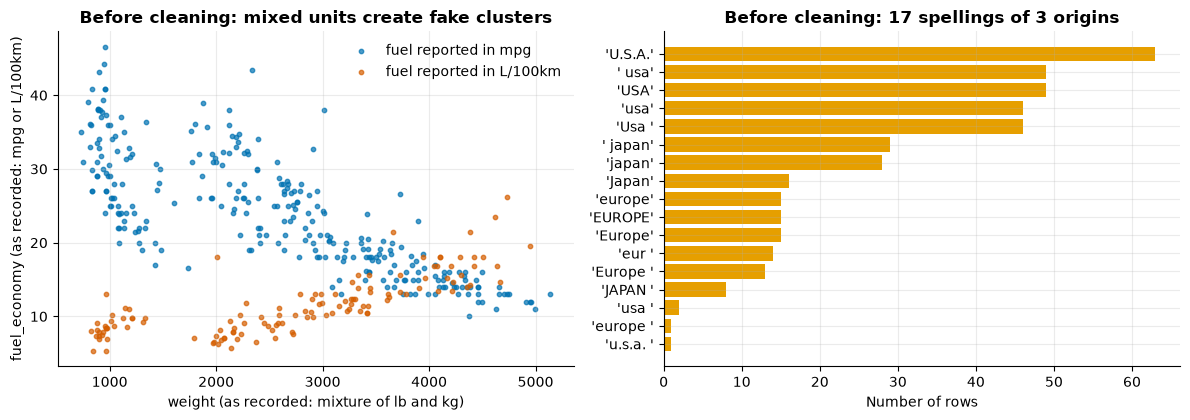

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for unit, c in [("mpg", PALETTE[0]), ("L/100km", PALETTE[3])]:
    sel = messy["fuel_unit"] == unit
    axes[0].scatter(messy.loc[sel, "weight"], messy.loc[sel, "fuel_economy"], s=10, color=c, alpha=0.7,
                    label=f"fuel reported in {unit}")
axes[0].set_xlabel("weight (as recorded: mixture of lb and kg)")
axes[0].set_ylabel("fuel_economy (as recorded: mpg or L/100km)")
axes[0].set_title("Before cleaning: mixed units create fake clusters")
axes[0].legend()
counts = messy["origin"].value_counts()
axes[1].barh([repr(k) for k in counts.index], counts.values, color=PALETTE[1])
axes[1].invert_yaxis()
axes[1].set_xlabel("Number of rows")
axes[1].set_title(f"Before cleaning: {len(counts)} spellings of 3 origins")
fig.tight_layout()
savefig("messy_before")
plt.show()

### 5.2 A reusable cleaning function

Each step is small, named and in a fixed order. Converting units **before** de-duplicating matters:
near-duplicates only become exact duplicates once the formatting and units agree.

In [20]:
ORIGIN_MAP = {"usa": "usa", "u.s.a.": "usa", "japan": "japan", "europe": "europe", "eur": "europe"}
BOOL_MAP = {"yes": True, "y": True, "true": True, "1": True, "no": False, "n": False, "false": False, "0": False}
DOMAIN_LIMITS = {                       # physically plausible ranges for 1970-82 cars
    "mpg": (5, 60), "cylinders": (3, 12), "displacement": (50, 500), "horsepower": (40, 300),
    "weight": (1000, 6000), "acceleration": (5, 30), "model_year": (1970, 1982),
}

def clean_mpg(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """Clean the messy Auto-MPG export. Returns a new DataFrame; the input is not modified."""
    out = df.copy()
    log = []
    # 1. strings: strip whitespace, normalise case
    out["name"] = out["name"].str.strip().str.lower().str.replace(r"\s+", " ", regex=True)
    out["origin"] = out["origin"].str.strip().str.lower().map(ORIGIN_MAP)
    assert out["origin"].notna().all(), "unknown origin spelling - extend ORIGIN_MAP"
    # 2. text -> numbers
    out["horsepower"] = pd.to_numeric(out["horsepower"].str.extract(r"(\d+\.?\d*)")[0], errors="coerce")
    log.append(f"horsepower: {out['horsepower'].isna().sum()} unknown ('?') -> NaN")
    # 3. units -> one canonical unit per column
    is_l100 = out["fuel_unit"].eq("L/100km")
    out["mpg"] = np.where(is_l100, L100KM_FROM_MPG / out["fuel_economy"], out["fuel_economy"]).round(1)
    is_kg = out["weight_unit"].eq("kg")
    out["weight"] = np.where(is_kg, out["weight"] * LB_PER_KG, out["weight"]).round(0).astype(int)
    log.append(f"converted {is_l100.sum()} L/100km -> mpg and {is_kg.sum()} kg -> lb")
    out["model_year"] = np.where(out["model_year"] < 100, out["model_year"] + 1900, out["model_year"])
    # 4. booleans, categoricals, dates
    out["turbo"] = out["turbo"].str.strip().str.lower().map(BOOL_MAP).astype(bool)
    out["origin"] = pd.Categorical(out["origin"], categories=["usa", "europe", "japan"])
    out["registered"] = pd.to_datetime(out["registered"], format="%Y-%m-%d", errors="coerce")
    # 5. domain limits: impossible values become NaN (not deleted - the rest of the row is fine)
    for col, (lo, hi) in DOMAIN_LIMITS.items():
        bad = ~out[col].between(lo, hi) & out[col].notna()
        if bad.any():
            log.append(f"{col}: {bad.sum()} value(s) outside [{lo}, {hi}] -> NaN")
            out[col] = out[col].astype(float).mask(bad)
    out["cylinders"] = out["cylinders"].astype("Int64")
    # 6. duplicates (after normalisation, so near-duplicates are caught too)
    cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration",
            "model_year", "origin", "name", "turbo", "registered"]
    out = out[cols]
    n_before = len(out)
    out = out.drop_duplicates()
    log.append(f"dropped {n_before - len(out)} duplicate rows")
    if verbose:
        print("\n".join("  - " + line for line in log))
    return out

clean = clean_mpg(messy)
print(clean.shape)
clean.head()

  - horsepower: 6 unknown ('?') -> NaN
  - converted 126 L/100km -> mpg and 114 kg -> lb
  - cylinders: 1 value(s) outside [3, 12] -> NaN
  - displacement: 1 value(s) outside [50, 500] -> NaN
  - acceleration: 1 value(s) outside [5, 30] -> NaN
  - dropped 12 duplicate rows
(398, 11)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,turbo,registered
172,25.0,4,90.0,71.0,2223,16.5,1975,europe,volkswagen dasher,True,1975-01-07
137,13.0,8,350.0,150.0,4699,14.5,1974,usa,buick century luxus (sw),False,1974-10-04
126,21.0,6,200.0,NaN,2875,17.0,1974,usa,ford maverick,False,1974-09-20
94,13.0,8,440.0,215.0,4735,11.0,1973,usa,chrysler new yorker brougham,False,1973-03-15
72,15.0,8,304.0,150.0,3892,12.5,1972,usa,amc matador (sw),False,1972-08-10


### 5.3 Validate with assertions

Cleaning code should **fail loudly** when new data breaks an assumption. A validation function with
plain `assert`s is the lightweight version of tools like *pandera* or *Great Expectations*.

In [21]:
EXPECTED_COLUMNS = {"mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration",
                    "model_year", "origin", "name", "turbo", "registered"}

def validate_mpg(df: pd.DataFrame) -> None:
    """Run every check, then fail with the list of all violated expectations."""
    checks = {"expected columns": lambda: set(df.columns) == EXPECTED_COLUMNS,
              "no duplicate rows": lambda: not df.duplicated().any()}
    for col, (lo, hi) in DOMAIN_LIMITS.items():
        checks[f"{col} numeric"] = lambda col=col: pd.api.types.is_numeric_dtype(df[col])
        checks[f"{col} in [{lo}, {hi}]"] = lambda col=col, lo=lo, hi=hi: df[col].dropna().between(lo, hi).all()
    checks.update({
        "origin in {usa, europe, japan}": lambda: set(df["origin"].unique()) <= {"usa", "europe", "japan"},
        "turbo is bool": lambda: df["turbo"].dtype == bool,
        "registered is datetime": lambda: pd.api.types.is_datetime64_any_dtype(df["registered"]),
        "names normalised": lambda: (df["name"] == df["name"].str.strip().str.lower()).all(),
        "< 5% NaN in mpg and horsepower": lambda: max(df["mpg"].isna().mean(), df["horsepower"].isna().mean()) < 0.05,
    })
    failed = []
    for name, fn in checks.items():
        try:
            ok = bool(fn())
        except Exception:          # e.g. comparing strings with numbers, missing column
            ok = False
        if not ok:
            failed.append(name)
    assert not failed, f"{len(failed)} of {len(checks)} checks failed: " + "; ".join(failed)
    print(f"✓ all {len(checks)} checks passed for {len(df)} rows")

validate_mpg(clean)

✓ all 21 checks passed for 398 rows


The checks also protect us against *regressions*: validation fails immediately on the raw file.

In [22]:
try:
    validate_mpg(messy.rename(columns={"fuel_economy": "mpg"}).drop(columns=["fuel_unit", "weight_unit"]))
except AssertionError as e:
    print("AssertionError:", e)

AssertionError: 12 of 21 checks failed: no duplicate rows; cylinders in [3, 12]; displacement in [50, 500]; horsepower numeric; horsepower in [40, 300]; weight in [1000, 6000]; acceleration in [5, 30]; model_year in [1970, 1982]; origin in {usa, europe, japan}; turbo is bool; registered is datetime; names normalised


### 5.4 Before / after

Because we created the mess ourselves, we know the truth (the original `mpg.csv`) — a luxury you never
have in practice. The index of the messy frame is the original row number, so we can compare directly.

In [23]:
original = load_mpg()
aligned = clean.sort_index()
print("rows: messy", len(messy), "-> clean", len(clean), "| original", len(original))
print("index identical to original:", aligned.index.equals(original.index))
for col in ["mpg", "weight", "horsepower", "displacement", "acceleration", "cylinders"]:
    diff = (aligned[col].astype(float) - original[col]).abs()
    print(f"{col:13s} max |clean - original| = {diff.max():.2f}   NaN introduced by domain checks: "
          f"{aligned[col].isna().sum() - original[col].isna().sum()}")
print("origin identical:", (aligned["origin"].astype(str) == original["origin"]).all())
print("name identical  :", (aligned["name"] == original["name"]).all())

rows: messy 410 -> clean 398 | original 398
index identical to original: True
mpg           max |clean - original| = 0.00   NaN introduced by domain checks: 0
weight        max |clean - original| = 0.00   NaN introduced by domain checks: 0
horsepower    max |clean - original| = 0.00   NaN introduced by domain checks: 0
displacement  max |clean - original| = 0.00   NaN introduced by domain checks: 1
acceleration  max |clean - original| = 0.00   NaN introduced by domain checks: 1
cylinders     max |clean - original| = 0.00   NaN introduced by domain checks: 1
origin identical: True
name identical  : True


In [24]:
num_cols = ["mpg", "weight", "model_year"]
before = messy.rename(columns={"fuel_economy": "mpg"})[num_cols].describe().T[["count", "mean", "min", "max"]]
after = clean[num_cols].describe().T[["count", "mean", "min", "max"]]
pd.concat({"messy": before, "clean": after, "original": original.assign(model_year=original["model_year"] + 1900)[num_cols]
           .describe().T[["count", "mean", "min", "max"]]}, axis=1).round(1)

messy                         clean                         original                        
            count    mean    min     max  count    mean     min     max    count    mean     min     max
mpg         410.0    20.1    5.3    46.6  398.0    23.5     9.0    46.6    398.0    23.5     9.0    46.6
weight      410.0  2603.6  731.6  5140.0  398.0  2970.4  1613.0  5140.0    398.0  2970.4  1613.0  5140.0
model_year  410.0   840.6   70.0  1982.0  398.0  1976.0  1970.0  1982.0    398.0  1976.0  1970.0  1982.0

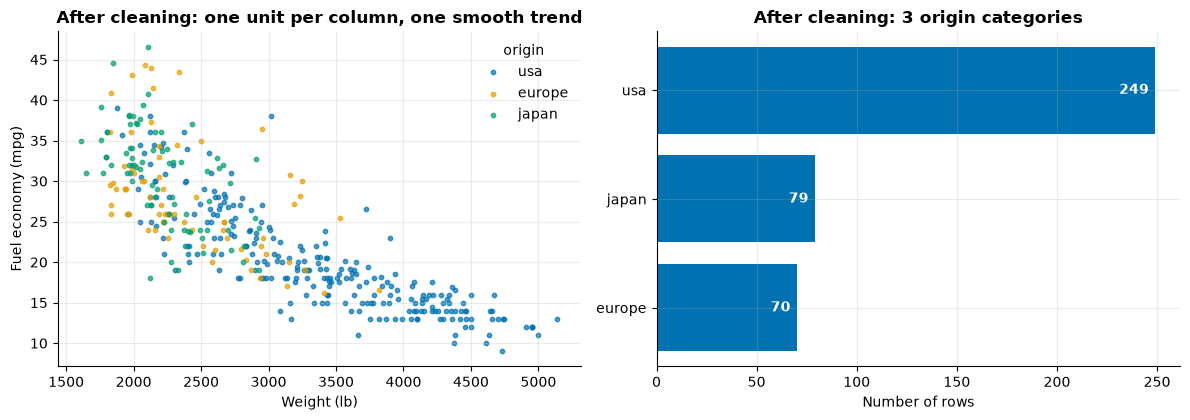

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for o, c in zip(["usa", "europe", "japan"], PALETTE):
    sel = clean["origin"] == o
    axes[0].scatter(clean.loc[sel, "weight"], clean.loc[sel, "mpg"], s=10, color=c, alpha=0.7, label=o)
axes[0].set_xlabel("Weight (lb)")
axes[0].set_ylabel("Fuel economy (mpg)")
axes[0].set_title("After cleaning: one unit per column, one smooth trend")
axes[0].legend(title="origin")
counts = clean["origin"].value_counts()
axes[1].barh(counts.index.astype(str), counts.values, color=PALETTE[0])
for i, v in enumerate(counts.values):
    axes[1].text(v - 3, i, str(v), va="center", ha="right", color="white", fontweight="bold")
axes[1].invert_yaxis()
axes[1].set_xlabel("Number of rows")
axes[1].set_title("After cleaning: 3 origin categories")
fig.tight_layout()
savefig("messy_after")
plt.show()

## Key takeaways

- **Look at missingness** (bar chart + matrix) and ask *why* values are missing: MCAR, MAR or MNAR.
- Mean imputation is a baseline, not a solution: it collapses variance. Group-wise, KNN or iterative
  imputers use the MAR structure; a **missing indicator** keeps the signal in the missingness itself.
- Imputers, like all fitted transformers, go **inside the pipeline** (fit on training folds only).
- Outlier rules disagree; for skewed data IQR flags legitimate values. Prefer **domain limits** for
  errors and transforms/robust models for legitimate extremes.
- **Normalise before de-duplicating**: near-duplicates hide behind case, whitespace and units.
- Wrap cleaning in a **function** and guard it with **assertions** so new data fails loudly.

## Exercises

1. **MNAR thought experiment.** Give an example where `age` on the Titanic could be MNAR. Can any test
   on the observed data prove it? *Hint: what would have to depend on the unobserved age itself?*
2. **Imputation in CV.** Compare `SimpleImputer(median)`, `KNNImputer` and `IterativeImputer` inside a
   logistic-regression pipeline on Titanic with 5-fold CV. Does better imputation accuracy translate to
   better survival prediction? *Hint: swap the imputer in `make_model`.*
3. **Robust z on MPG.** Apply the robust-z rule to every numeric column of the clean Auto-MPG data. Which
   cars are flagged, and are they errors? *Hint: `(x - x.median()) / (1.4826 * MAD)`.*
4. **Break the pipeline.** Add a new origin spelling `"Deutschland"` to a messy row and re-run
   `clean_mpg`. What happens and how would you extend the function? *Hint: look at the first `assert`.*
5. **Near-duplicate detection without exact matching.** Find pairs of rows in the clean data with the same
   `name` and `model_year` and weights within 1 %. *Hint: `merge` the frame with itself on name and year.*